In [ ]:
# April 15, 2026
# working to verify the dim, tau scaling for HMC
# import numpy as np
import jax
jax.config.update("jax_enable_x64", True)
from jax import jit

import jax.random as jr
import jax.numpy as jnp
from datatypes import QP, IntegratorConfig
from target import gen_perturb_precision
from hamiltonian import gaussian_hamiltonian
from sampler import hmc_sampler, chmc_sampler, extract_positions, extract_energy
from metrics import compute_accept_rate

import time

import numpy as np

In [66]:
# initial key
key = jax.random.PRNGKey(1)

# dimensions
dim = 2
Mass_inv = jnp.eye(dim)
high_κ_vec = jnp.array([101, -99])
κ100_mat = jnp.array([high_κ_vec, high_κ_vec[::-1]])
bias = jnp.linalg.det(κ100_mat)

target_mat = jnp.eye(dim)
H = gaussian_hamiltonian(target_mat, mass_inv=Mass_inv)
H_flat = lambda qp_flat: H(QP.from_array(qp_flat))

# Set parameters
tau = 0.025
T = 1.0
N = int(jnp.floor(T / tau))
tol = 1e-2
max_iter = 2

config = IntegratorConfig(τ=tau,
                          T=T,
                          N=N,
                          tol=tol,
                          max_iter = max_iter)

# random draw keys
burnin_samples = 30
mainnum_samples = 1000
burninkey, mainkey1, mainkey2 = jr.split(key, 3)
keys_init = jr.split(burninkey, burnin_samples)
hmckeys_main = jr.split(mainkey1, mainnum_samples)
chmckeys_main = jr.split(mainkey2, mainnum_samples)

# initial qp-sample
qp_init = jr.normal(key, shape=(2 * dim,))
qp_init = QP.from_array(qp_init)
# initial kernel state
init_sample = [qp_init.to_array(), 1, False]

In [67]:
# ========================================
# HMC: Single Shot
# ========================================
# compile
start = time.time()
jhmc_sampler = jit(hmc_sampler, static_argnums=(2, 3))
sample_hmc = jhmc_sampler(init_sample, keys_init, H_flat, config)
jax.block_until_ready(sample_hmc)
end = time.time()
print(f"burn in run {burnin_samples} samples: {end - start: .3e}, \n single run {(end - start)/burnin_samples: .3e}")
# main run
start = time.time()
sample_hmc = jhmc_sampler(init_sample, hmckeys_main,  H_flat, config)
jax.block_until_ready(sample_hmc)
end = time.time()
print(
    f"Main run:\n {mainnum_samples} runs: {end - start: .3e} \n 1 run:  {(end-start)/mainnum_samples: .3e}"
)

burn in run 30 samples:  4.859e-01, 
 single run  1.620e-02
Main run:
 1000 runs:  3.299e-01 
 1 run:   3.299e-04


In [68]:
# ========================================
# CHMC: Single Shot
# ========================================
start = time.time()
jchmc_sampler = jit(chmc_sampler, static_argnums=(2,3,4))
sample_chmc = jchmc_sampler(init_sample, keys_init, H_flat, config)
jax.block_until_ready(sample_chmc)
end = time.time()
print(f"CHMC burn in run {burnin_samples} samples: {end - start: .3e}, \n single run {(end - start)/burnin_samples: .3e}")
start = time.time()
sample_chmc = jchmc_sampler(init_sample, hmckeys_main, H_flat, config)
jax.block_until_ready(sample_chmc)
end = time.time()
print(
    f"CHMC Main run:\n {mainnum_samples} runs: {end - start:.2f} \n     1 run:  {(end-start)/mainnum_samples: .3e}"
)

CHMC burn in run 30 samples:  5.233e-01, 
 single run  1.744e-02
CHMC Main run:
 1000 runs: 0.44 
     1 run:   4.403e-04


In [69]:
jnp.logspace(1,8, 8,endpoint=True, base=2)

Array([  2.,   4.,   8.,  16.,  32.,  64., 128., 256.], dtype=float64)

In [74]:
# ========================================
# CHMC v HMC: fixed κ, τ sweep
# ========================================
# dim = 2
numdims = 8
dims = np.logspace(1,8, numdims,endpoint=True, base=2, dtype=int)
c_step = 11
runs = 20
τcounts = np.array([5, 10, 20, 40, 80, 160])
τs = 1/τcounts
numτs = len(τs)
perturb_val = jnp.arange(c_step)/((c_step-1)*2)
mcmc_min_exp = 2
mcmc_max_exp = 3
mcmc_iter_count = 7
lens = jnp.logspace(mcmc_min_exp, mcmc_max_exp, mcmc_iter_count, base=10, dtype=int)
hmc_chainring = []
chmc_chainring = []
# hmcΔH_ring = []
# chmcΔH_ring = []
hmc_acceptrates = []
chmc_acceptrates = []
chainringindex = []
true_matrices = []

totaltime = time.time()

jhmc_sampler = jit(hmc_sampler, static_argnums=(2,3))
jchmc_sampler = jit(chmc_sampler, static_argnums=(2,3,4))


key1, key2, key3 = jr.split(key, 3)
keyring = jr.split(key1, numτs)
chmckeyring = jr.split(key2, numτs*len(lens)*runs)
hmckeyring = jr.split(key3, numτs*len(lens)*runs)

high_κ_vec = jnp.array([101, -99])
κ100_mat = jnp.array([high_κ_vec, high_κ_vec[::-1]])
for l, dim in enumerate(dims):
    print(f'{l+1} of {len(dims)}')
    pval = perturb_val[-3]
    Mass_inv = jnp.eye(dim)
    target_mat = jnp.eye(dim)
    true_matrices.append(target_mat)
    H = gaussian_hamiltonian(target_mat, mass_inv=Mass_inv)
    H_flat = lambda qp_flat, H=H: H(QP.from_array(qp_flat))    
    for k,val in enumerate(τs):
        qp_init = jr.normal(keyring[k], shape=(2 * dim,))
        init_sample = [qp_init, 1, False]
    # only doing one dim right now 
        tau = 0.05
        T = 1.0
        N = int(jnp.ceil(T / tau))
        tol = 1e-2
        max_iter = 2
        config = IntegratorConfig(τ=val,
                                T=T,
                                N=N,
                                tol=tol,
                                max_iter = max_iter)
        
        for j, mainnum_samples in enumerate(lens):
            for i in range(runs):
                hmc_keys_main = jr.split(hmckeyring[k+j+i], mainnum_samples)

                # HMC samples
                
                start = time.time()
                sample_hmc = jhmc_sampler(init_sample, hmc_keys_main, H_flat, config)
                jax.block_until_ready(sample_hmc)
                end = time.time()
                # print(f"HMC Main run:\n ({dim}, {val: .2f}, {mainnum_samples}) runs: {end - start:.2f} \n 1 run:  {(end-start)/mainnum_samples: .3e}")
                hmc_chainring.append(extract_positions(sample_hmc, accepted_only=True))
                hmc_acceptrates.append(compute_accept_rate(sample_hmc))

    print(f"HMC v CHMC Chain Gen Total Time: {time.time() - totaltime:.3f}")

1 of 8
HMC v CHMC Chain Gen Total Time: 21.649
2 of 8
HMC v CHMC Chain Gen Total Time: 48.229
3 of 8
HMC v CHMC Chain Gen Total Time: 70.542
4 of 8
HMC v CHMC Chain Gen Total Time: 97.801
5 of 8
HMC v CHMC Chain Gen Total Time: 141.260
6 of 8
HMC v CHMC Chain Gen Total Time: 203.974
7 of 8
HMC v CHMC Chain Gen Total Time: 382.389
8 of 8
HMC v CHMC Chain Gen Total Time: 1141.370


In [75]:
# ========================================
# τChain Ring: Analysis
# (dim, numτs, len, run)
# ========================================
import metrics
# CHMC
# chmc_cov_matrices = []
# cov_τmat_id = []
# for i,chain in enumerate(chmc_chainring):
#     chmc_cov_matrices.append(metrics.cov(chain))
#     cov_τmat_id.append(i)
# chmc_cov_matrices = jnp.array(chmc_cov_matrices).reshape(numτs,mcmc_iter_count,runs,dim,dim)

# HMC
hmc_cov_matrices = []


for chain in hmc_chainring:
    hmc_cov_matrices.append(metrics.cov(chain))
        # hmc_cov_matrices[i] = jnp.array(hmc_cov_matrices).reshape(numdims, numτs,mcmc_iter_count,runs,dim,dim)

true_cov_matrices = [jnp.linalg.inv(m) for m in true_matrices]


In [76]:
# ========================================
# τCHMC Chain Ring: Analysis
# Downstream analytics
# ring.shape: (dims, numτs, len, run)
# ========================================

hmc_cov_metric = []
counter = numτs*len(lens)*runs
for j, true_mat in enumerate(true_cov_matrices):
    for i in range(counter):
        hmc_cov_metric.append(metrics.maxtracediff(hmc_cov_matrices[j*counter + i], true_mat))
hmc_cov_metric = jnp.array(hmc_cov_metric)
hmc_cov_metric = hmc_cov_metric.reshape(numdims, numτs, len(lens), runs)


In [ ]:
hmc_acceptrates = jnp.array(hmc_acceptrates)


In [81]:
hmc_acceptrates = hmc_acceptrates.reshape(numdims, numτs, len(lens), runs)

In [98]:
hmc_acceptrates[0][0].mean()

Array(0.9964931, dtype=float32)

In [91]:
dims[0]

np.int64(2)

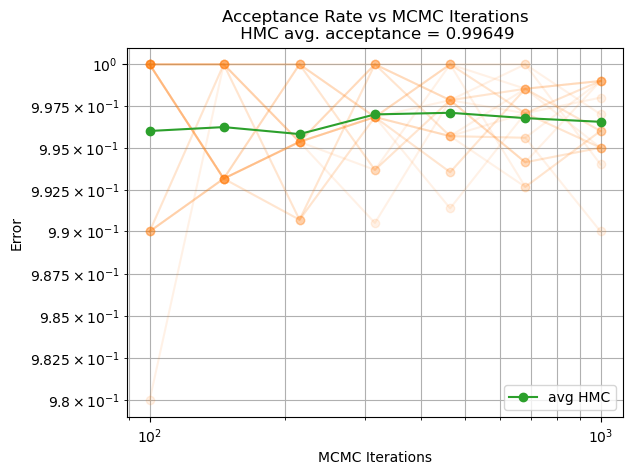

In [104]:
from matplotlib import pyplot as plt
# from plotting import gen_plots

def gen_τ_plots_no_chmc(lens, 
              hmc_metrics, 
              config, 
              i, 
              dims,
              cond = 1,
              slope=False, 
              avg=True,
              avg_avg = False,
              title = 'Cov Max Diag Err versus MCMC Iterations'
              ):
    # plt.loglog(lens, chmc_metrics[i,:], '-*', color = 'C0', alpha = 0.15)
    plt.loglog(lens, hmc_metrics[i,:], '-o', color = 'C1', alpha = 0.1)
    title = title
    subtitle1 = f'\n$dim$ = {dims}, $\kappa$ = {cond: 0.2f}, $\\tau = $ {config.τ}, $N = $ {config.N}'
    subtitle1 = ''
    subtitle2 = ''
    if avg:
        # avg_chmc = np.mean(chmc_metrics[i,:], axis = 1)
        # plt.loglog(lens, avg_chmc, '-*', color = 'C0', label ='avg CHMC', alpha = 1)
        avg_hmc = np.mean(hmc_metrics[i,:], axis = 1)
        plt.loglog(lens, avg_hmc , '-o', color = 'C2', label ='avg HMC', alpha = 1)
        if avg_avg:
            avg_avg = hmc_metrics[i,:].mean()
            subtitle2 = f'\n HMC avg. acceptance = {avg_avg:.5f}'
            # combined subtitle
            plt.title(title+subtitle1+subtitle2)
        if slope:
            # chmc_p = np.polyfit(np.log(lens), np.log(avg_chmc), 1)
            hmc_p = np.polyfit(np.log(lens), np.log(avg_hmc), 1)

            # slop of avg chain subtitle
            subtitle2 = f'\n HMC avg. slope = {hmc_p[0]:.5f}'

            # combined subtitle
            plt.title(title+subtitle1+subtitle2)
    else:
        plt.title(title + subtitle1)
    plt.xlabel('MCMC Iterations')
    plt.ylabel('Error')
    plt.grid(which='minor')
    plt.grid(which='major')
    plt.legend()
gen_τ_plots_no_chmc(lens, hmc_acceptrates[0], config, 0, dims=dims[0], cond = 1, slope=False, avg = True, avg_avg=True, title="Acceptance Rate vs MCMC Iterations")

In [46]:
hmc_cov_metric.shape

(8, 6, 7, 20)

In [50]:
for i, dim in enumerate(dims):
    for j,val in enumerate(τs):
        print(i,j)

0 0
0 1
0 2
0 3
0 4
0 5
1 0
1 1
1 2
1 3
1 4
1 5
2 0
2 1
2 2
2 3
2 4
2 5
3 0
3 1
3 2
3 3
3 4
3 5
4 0
4 1
4 2
4 3
4 4
4 5
5 0
5 1
5 2
5 3
5 4
5 5
6 0
6 1
6 2
6 3
6 4
6 5
7 0
7 1
7 2
7 3
7 4
7 5


In [59]:
dims

array([  2,   4,   8,  16,  32,  64, 128, 256])

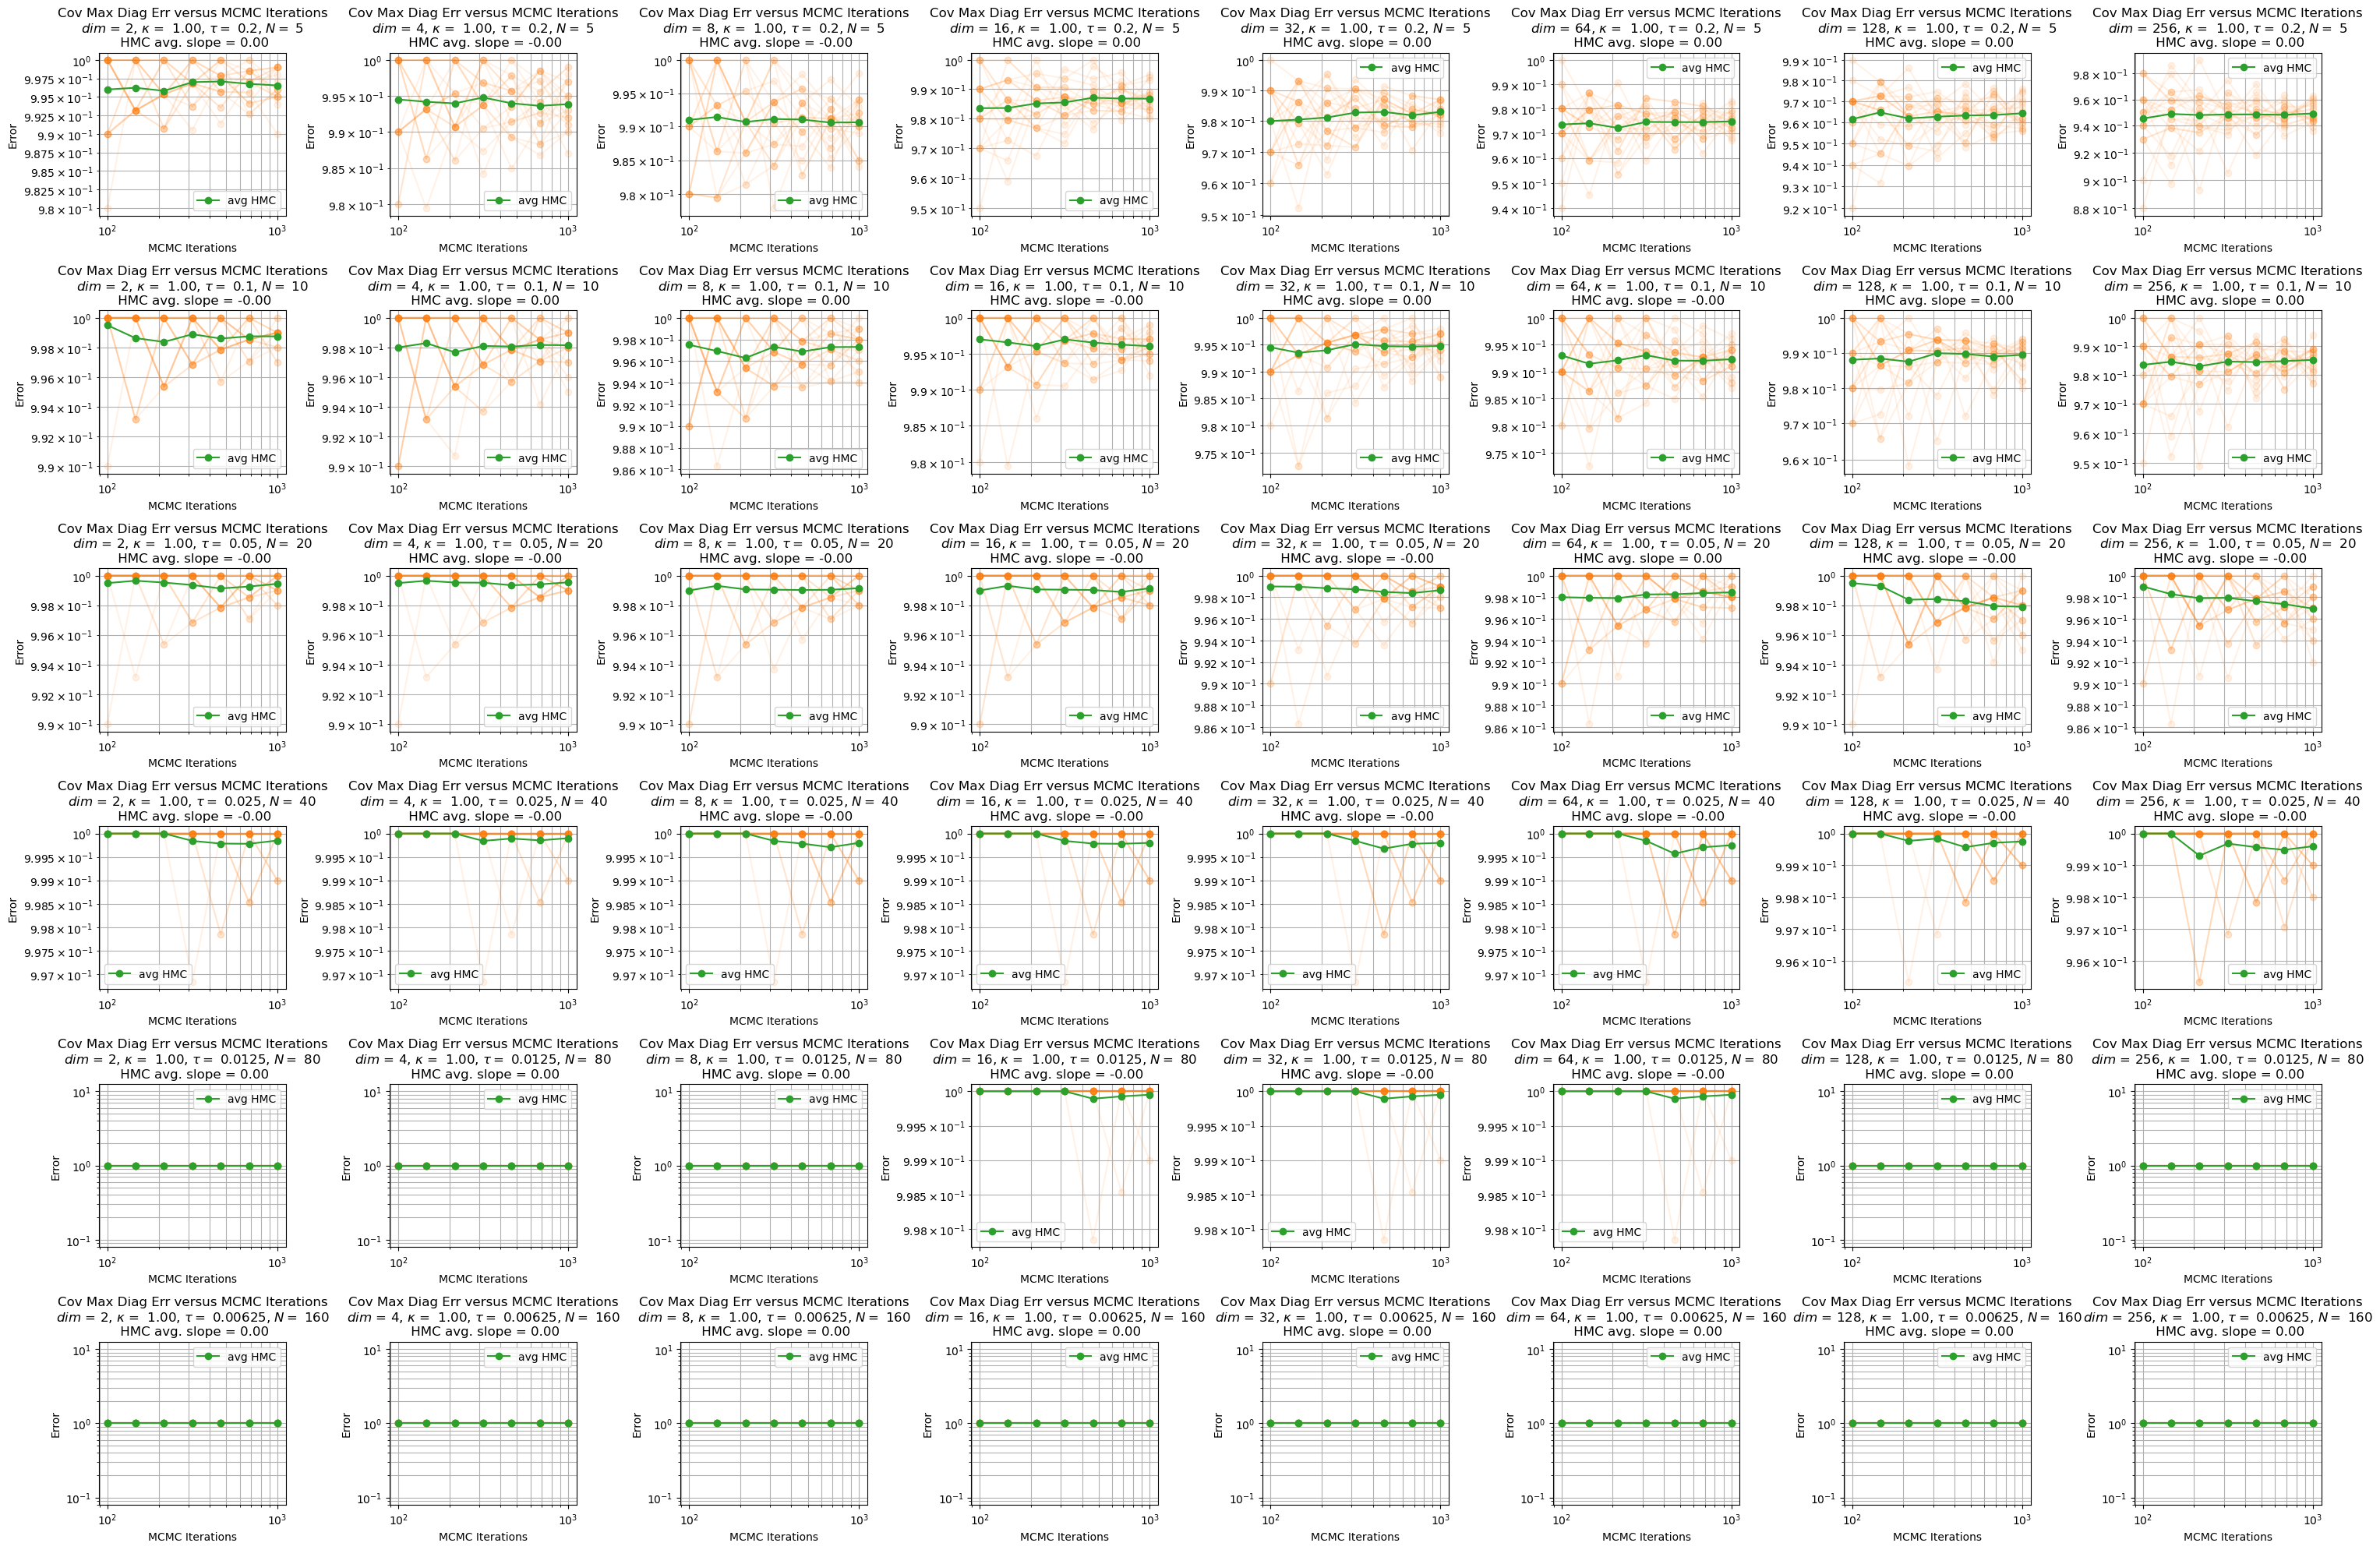

In [97]:
fig, axes = plt.subplots(6, 8, figsize=(30, 20))

for i, dim in enumerate(dims):
    for j,val in enumerate(τs):
    # only doing one dim right now 
        T = 1.0
        N = int(jnp.ceil(T / val))
        tol = 1e-2
        max_iter = 2
        config = IntegratorConfig(τ=val,
                                T=T,
                                N=N,
                                tol=tol,
                                max_iter = max_iter)
        plt.sca(axes[j, i])
        gen_τ_plots_no_chmc(lens, hmc_acceptrates[i], config, j, dims=dim, cond = 1, slope=True)

plt.tight_layout()
plt.show()

In [64]:
hmc_chainring[0][0].dtype

dtype('float32')

In [ ]:
from scipy.stats import ecdf
testcdf = ecdf(hmc_chain[1])

In [ ]:
from scipy.stats import wasserstein_distance_nd as w1_dist_nd
from scipy.stats import ecdf
numpoints = 201
minval = -1
maxval = 1
x = np.linspace( minval, maxval, numpoints)
y = np.linspace( minval, maxval, numpoints)
X, Y = np.meshgrid(x,y)
XY = np.stack([X,Y], axis=-1)

AXY = XY @ κ100_mat.T
Z   = np.einsum('...i,...i->...', XY, AXY)
pdf = np.exp(-0.5 * Z)          
pdf /= pdf.sum()   

testcdf = ecdf(hmc_chain[1])

w1 = w1_dist_nd(
    hmc_chainring[1],   # (96, 2)  — uniform weights (1/96 each)
    XY,           # (N*N, 2) — reference distribution points
    v_weights=pdf
)
print(f"Wasserstein-1 (2D): {w1:.6f}")

In [ ]:
import numpy as np
from scipy.stats import wasserstein_distance_nd

# ── 1. Build grid and evaluate PDF ──────────────────────────────────────────
N = 201
x = np.linspace(-3, 3, N)
y = np.linspace(-3, 3, N)
Gx, Gy = np.meshgrid(x, y)
grid = np.stack([Gx, Gy], axis=-1).reshape(-1, 2)  # (N*N, 2)

AXY_grid = grid @ np.array(κ100_mat).T              # (N*N, 2)
Z_grid   = np.einsum('...i,...i->...', grid, AXY_grid)  # (N*N,)
pdf_grid = np.exp(-0.5 * Z_grid)                    # (N*N,)
pdf_grid /= pdf_grid.sum()                          # normalise to weights
M = 200
idx = np.random.choice(len(grid), size=M, p=pdf_grid)
pdf_samples = grid[idx]     
# ── 2. Wasserstein-1 ─────────────────────────────────────────────────────────
w1 = wasserstein_distance_nd(
    hmc_chainring[1],   # (96, 2)  — your sample, uniform weights
    pdf_samples
)
print(f"Wasserstein-1: {w1:.6f}")

In [ ]:
count = 20
M = 200
random_w1_distances = np.zeros(count)
for i in range(count):
        idx = np.random.choice(len(grid), size=M, p=pdf_grid)
        pdf_samples = grid[idx]   
        random_w1_distances[i] = w1 = wasserstein_distance_nd(
                    hmc_chainring[1],   # (96, 2)  — your sample, uniform weights
                    pdf_samples)


In [ ]:
# ========================================
# τCHMC Chain Ring: Wasserstein Analysis
# ring.shape: (numτs, len, run )

# Need to compare chain accepted num samples to similar PDF num samples

# ========================================

from scipy.stats import wasserstein_distance_nd

# ── 1. Build grid and evaluate PDF ──────────────────────────────────────────
N = 201
x = np.linspace(-3, 3, N)
y = np.linspace(-3, 3, N)
Gx, Gy = np.meshgrid(x, y)
grid = np.stack([Gx, Gy], axis=-1).reshape(-1, 2)  # (NxN, 2)

AXY_grid = grid @ np.array(κ100_mat).T              # (NxN, 2)
Z_grid   = np.einsum('...i,...i->...', grid, AXY_grid)  
pdf_grid = np.exp(-0.5 * Z_grid)                    
pdf_grid /= pdf_grid.sum()                          

# random subset of points from grid. could actually just do uniformly chose points but whatever for now
M = 100
idx = np.random.choice(len(grid), size=M, p=pdf_grid)
pdf_samples = grid[idx]     

w1 = wasserstein_distance_nd(
    hmc_chainring[1],  
    pdf_samples # might be incorrect comparison here
)





In [ ]:
import metrics
# This takes like 35 min to run
# τCHMC Chain Ring: Wasserstein Analysis
# ring.shape: (numτs, len, run )


# CHMC
chmc_w1_dist = []
for i,chain in enumerate(chmc_chainring):
    idx = np.random.choice(len(grid), size=M, p=pdf_grid)
    chmc_w1_dist.append(wasserstein_distance_nd(chmc_chainring[i],pdf_samples))
chmc_w1_dist = jnp.array(chmc_w1_dist).reshape(numτs,mcmc_iter_count,runs)

In [ ]:
# This takes like 39 min to run
# HMC
hmc_w1_dist = []
for i,chain in enumerate(hmc_chainring):
    idx = np.random.choice(len(grid), size=M, p=pdf_grid)
    hmc_w1_dist.append(wasserstein_distance_nd(hmc_chainring[i],pdf_samples))
hmc_w1_dist = jnp.array(hmc_w1_dist).reshape(numτs,mcmc_iter_count,runs)

In [ ]:
def gen_τ_plots(lens, 
              chmc_metrics, 
              hmc_metrics, 
              config, 
              i, 
              dims = dims,
              cond = conds,
              slope=False, 
              avg=True,
              title = 'Cov Max Diag Err versus MCMC Iterations'):
    plt.loglog(lens, chmc_metrics[i,:], '-*', color = 'C0', alpha = 0.15)
    plt.loglog(lens, hmc_metrics[i,:], '-o', color = 'C1', alpha = 0.15)
    title = title
    subtitle1 = f'\n$dim$ = {dims[0]}, $\kappa$ = {cond: 0.2f}, $\\tau = $ {config.τ}, $N = $ {config.N}'
    if avg:
        avg_chmc = np.mean(chmc_metrics[i,:], axis = 1)
        plt.loglog(lens, avg_chmc, '-*', color = 'C0', label ='avg CHMC', alpha = 1)
        avg_hmc = np.mean(hmc_metrics[i,:], axis = 1)
        plt.loglog(lens, avg_hmc , '-o', color = 'C1', label ='avg HMC', alpha = 1)
    if slope:
        chmc_p = np.polyfit(np.log(lens), np.log(avg_chmc), 1)
        hmc_p = np.polyfit(np.log(lens), np.log(avg_hmc), 1)

        # slop of avg chain subtitle
        subtitle2 = f'\n CHMC avg. slope = {chmc_p[0]:.2f}, HMC avg. slope = {hmc_p[0]:.2f}'

        # combined subtitle
        plt.title(title+subtitle1+subtitle2)
    else:
        plt.title(title + subtitle1)
    plt.xlabel('MCMC Iterations')
    plt.ylabel('Error')
    plt.grid(which='minor')
    plt.grid(which='major')
    plt.legend()
gen_τ_plots(lens, chmc_w1_dist, hmc_w1_dist, config, 0, dims=dims, cond = conds[-3], slope=True, title = 'W1 Metric vs MCMC Iterations')

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(30, 20))
axes = axes.flatten()

for i,val in enumerate(τs):
# only doing one dim right now 
    T = 1.0
    N = int(jnp.ceil(T / val))
    tol = 1e-2
    max_iter = 2
    config = IntegratorConfig(τ=val,
                            T=T,
                            N=N,
                            tol=tol,
                            max_iter = max_iter)
    plt.sca(axes[i])
    gen_τ_plots(lens, chmc_w1_dist, hmc_w1_dist, config, i, dims=dims, cond = conds[-3], slope=True, title = 'W1 Metric vs MCMC Iterations')

plt.tight_layout()
plt.show()